<a href="https://colab.research.google.com/github/Fakhar001/AIC354-Machine-Learning-Fundamentals/blob/main/ML_Lab_SSL_Label_Propagation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Core Intuition Behind Semi-Supervised Learning

The fundamental idea behind SSL is that **unlabeled data, even without explicit labels, contains valuable information about the underlying structure and distribution of the data.** While supervised learning focuses solely on the relationship between features and labels, SSL recognizes that the intrinsic properties of the data points themselves can help a model learn better.

Think of it like this:

*   **Supervised Learning (Purely Labeled):** You're given a few perfectly drawn maps with cities clearly marked. You learn to recognize cities only by looking at these marked maps.
*   **Unsupervised Learning (Purely Unlabeled):** You're given a huge pile of blank maps. You can try to group similar-looking regions or find natural clusters, but you don't know what those clusters represent.
*   **Semi-Supervised Learning (Labeled + Unlabeled):** You have a few perfectly drawn maps (labeled data) AND a huge pile of blank maps (unlabeled data). You use the marked maps to understand what cities look like, but then you use this understanding to infer where other cities might be on the blank maps, or at least understand the geographical patterns and relationships that exist across all maps. The blank maps provide context and structure that help you draw better conclusions about the marked maps, and vice versa.

In a more technical sense, SSL algorithms make the assumption that **data points that are close to each other in the feature space are likely to share the same label.** By observing patterns in the abundant unlabeled data, the model can form more robust decision boundaries or learn better representations, even with minimal initial supervision. This essentially allows the model to 'fill in the gaps' where labels are missing, guided by the structure revealed by the unlabeled examples.

### Code Implementation: Semi-Supervised Learning

In this section, we will implement a Semi-Supervised Learning model using `scikit-learn`. We'll use the **Label Propagation** algorithm, which works by 'spreading' labels from labeled data points to unlabeled ones based on their proximity.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation

# 1. Generate a synthetic dataset (Two Moons)
X, y = datasets.make_moons(n_samples=200, noise=0.1, random_state=42)

# 2. Simulate a scenario with mostly unlabeled data
# We will only keep labels for a few data points (e.g., 5%)
random_unlabeled_points = np.random.rand(len(y)) < 0.95
y_train = np.copy(y)
y_train[random_unlabeled_points] = -1  # -1 is the marker for unlabeled data in scikit-learn

print(f"Total points: {len(y)}")
print(f"Labeled points: {np.sum(y_train != -1)}")
print(f"Unlabeled points: {np.sum(y_train == -1)}")

Total points: 200
Labeled points: 6
Unlabeled points: 194


In [7]:
datasets.make_moons

<function sklearn.datasets._samples_generator.make_moons(n_samples=100, *, shuffle=True, noise=None, random_state=None)>

### Training the Model

Next, we train the `LabelPropagation` model. It uses the structure of the unlabeled data to infer the missing labels.

In [3]:
lp_model = LabelPropagation(kernel='knn', n_neighbors=7)
lp_model.fit(X, y_train)

# Predicted labels for all points
predicted_labels = lp_model.transduction_

# Check accuracy against the original 'ground truth' labels we hid
accuracy = lp_model.score(X, y)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 99.50%


In [8]:
predicted_labels

array([0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1])

In [9]:
lp_model

LabelPropagation(kernel='knn')

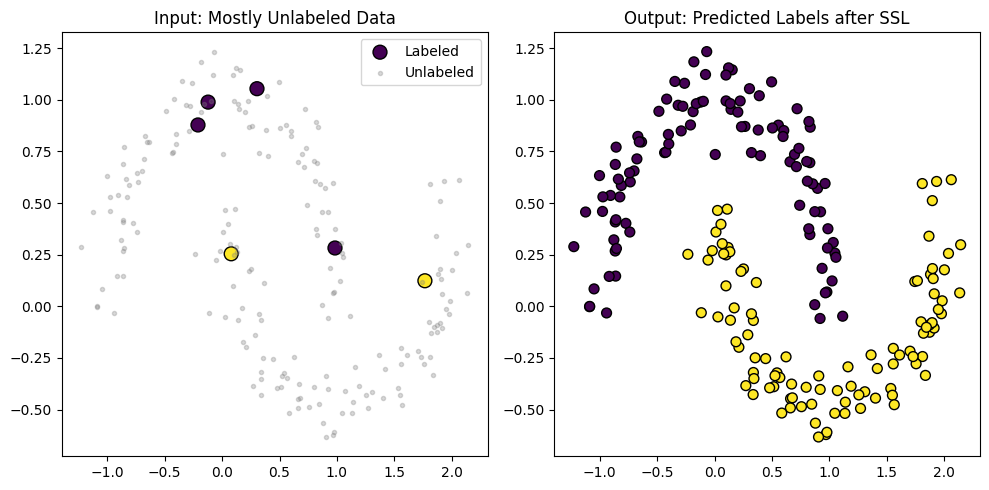

In [4]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y_train != -1, 0], X[y_train != -1, 1], c=y_train[y_train != -1], marker='o', s=100, edgecolors='k', label='Labeled')
plt.scatter(X[y_train == -1, 0], X[y_train == -1, 1], c='grey', marker='.', alpha=0.3, label='Unlabeled')
plt.title("Input: Mostly Unlabeled Data")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=predicted_labels, marker='o', s=50, edgecolors='k')
plt.title("Output: Predicted Labels after SSL")

plt.tight_layout()
plt.show()